# Tahap pertama yakni memvisualisasi terlebih dahulu data yang di pakai 
## yakni tahapan normalisasi sinyal, visualisasi channel, filtering untuk menghilangkan frekuensi rendah yang tidak relevan, sengmentasi sinyal 
<p> Tahap pertama dalam penelitian ini adalah memvisualisasikan dan menyiapkan data EEG yang digunakan. Pada tahap ini dilakukan serangkaian proses awal untuk memastikan kualitas sinyal sebelum dianalisis lebih lanjut. Proses tersebut meliputi normalisasi sinyal guna menyamakan skala amplitudo antar channel, visualisasi channel untuk meninjau pola aktivitas serta mendeteksi adanya noise atau artefak, filtering untuk menghilangkan komponen frekuensi rendah yang tidak relevan seperti baseline drift di bawah 0.5 Hz, dan segmentasi sinyal untuk membagi data EEG menjadi potongan-potongan pendek agar lebih mudah diproses pada tahap analisis atau pelatihan model (Han et al., 2025; Xia et al., 2025; Xiong et al., 2024).

## berikut untuk analisis data dari EEGDenoiseNet

In [6]:
import os
import glob

folder_path = r'C:\Users\akip\Desktop\EEGdenoiseNet\Data EEGDenoiseNet'

# Cari semua file .mat dalam folder
mat_files = glob.glob(os.path.join(folder_path, "*.mat"))
print("File .mat yang ditemukan:")
for file in mat_files:
    print(f"📁 {file}")
    
if mat_files:
    # Load file .mat pertama
    import scipy.io
    data = scipy.io.loadmat(mat_files[2])
    print(f"\nKeys dalam file: {list(data.keys())}")

File .mat yang ditemukan:
📁 C:\Users\akip\Desktop\EEGdenoiseNet\Data EEGDenoiseNet\EEG_all_epochs.mat
📁 C:\Users\akip\Desktop\EEGdenoiseNet\Data EEGDenoiseNet\EMG_all_epochs.mat
📁 C:\Users\akip\Desktop\EEGdenoiseNet\Data EEGDenoiseNet\EOG_all_epochs.mat

Keys dalam file: ['__header__', '__version__', '__globals__', 'EOG_all_epochs', 'fs']


In [7]:
eeg_data = scipy.io.loadmat(f'{folder_path}/EEG_all_epochs.mat')
emg_data = scipy.io.loadmat(f'{folder_path}/EMG_all_epochs.mat')
eog_data = scipy.io.loadmat(f'{folder_path}/EOG_all_epochs.mat')
    
print("=== EEG DATA ===")
print(f"Keys: {list(eeg_data.keys())}")
print(f"EEG shape: {eeg_data['EEG_all_epochs'].shape if 'EEG_all_epochs' in eeg_data else 'Not found'}")
    
print("\n=== EMG DATA ===")
print(f"Keys: {list(emg_data.keys())}")
print(f"EMG shape: {emg_data['EMG_all_epochs'].shape if 'EMG_all_epochs' in emg_data else 'Not found'}")
    
print("\n=== EOG DATA ===")
print(f"Keys: {list(eog_data.keys())}")
print(f"EOG shape: {eog_data['EOG_all_epochs'].shape if 'EOG_all_epochs' in eog_data else 'Not found'}")
print(f"Sampling rate: {eog_data['fs'][0,0] if 'fs' in eog_data else 'Not found'}")


=== EEG DATA ===
Keys: ['__header__', '__version__', '__globals__', 'EEG_all_epochs', 'fs']
EEG shape: (4514, 512)

=== EMG DATA ===
Keys: ['__header__', '__version__', '__globals__', 'EMG_all_epochs', 'fs']
EMG shape: (5598, 512)

=== EOG DATA ===
Keys: ['__header__', '__version__', '__globals__', 'EOG_all_epochs', 'fs']
EOG shape: (3400, 512)
Sampling rate: 256


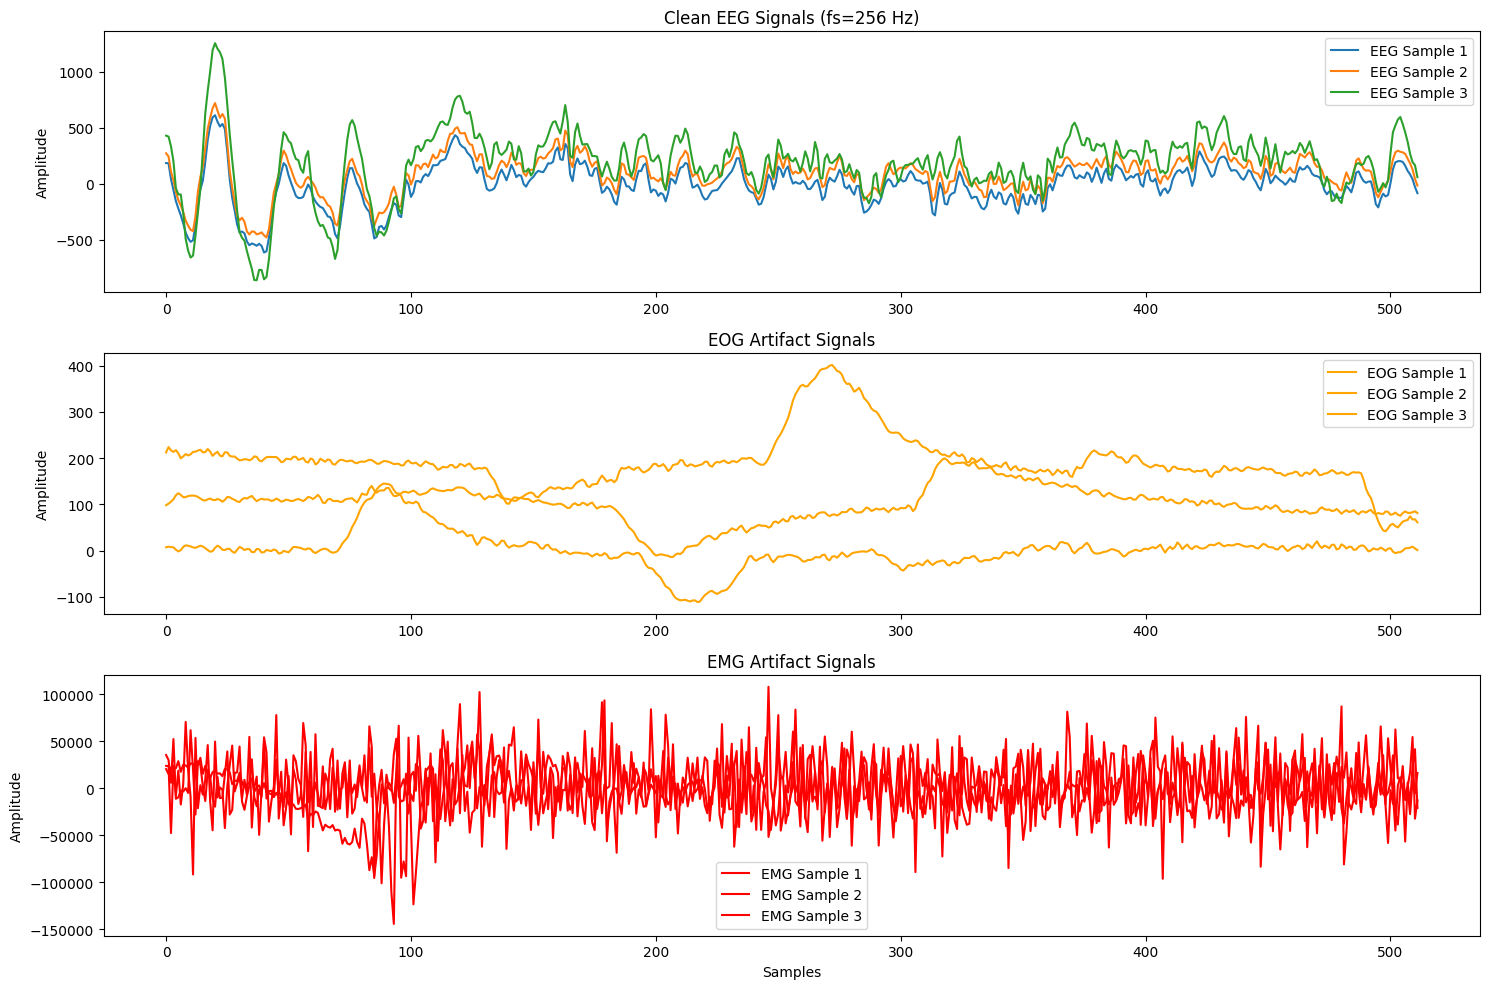

In [8]:
import matplotlib.pyplot as plt
def visualize_sample_data(eeg_data, emg_data, eog_data, num_samples=3):
    """Visualisasi contoh data dari setiap tipe"""
    
    fs = eog_data['fs'][0,0]  # Sampling rate
    
    plt.figure(figsize=(15, 10))
    
    # Plot EEG clean
    plt.subplot(3, 1, 1)
    if 'EEG_all_epochs' in eeg_data:
        eeg_samples = eeg_data['EEG_all_epochs'][:num_samples, :]
        for i in range(num_samples):
            plt.plot(eeg_samples[i] + i * 100, label=f'EEG Sample {i+1}')
        plt.title(f'Clean EEG Signals (fs={fs} Hz)')
        plt.ylabel('Amplitude')
        plt.legend()
    
    # Plot EOG artifacts
    plt.subplot(3, 1, 2)
    if 'EOG_all_epochs' in eog_data:
        eog_samples = eog_data['EOG_all_epochs'][:num_samples, :]
        for i in range(num_samples):
            plt.plot(eog_samples[i] + i * 100, label=f'EOG Sample {i+1}', color='orange')
        plt.title('EOG Artifact Signals')
        plt.ylabel('Amplitude')
        plt.legend()
    
    # Plot EMG artifacts
    plt.subplot(3, 1, 3)
    if 'EMG_all_epochs' in emg_data:
        emg_samples = emg_data['EMG_all_epochs'][:num_samples, :]
        for i in range(num_samples):
            plt.plot(emg_samples[i] + i * 100, label=f'EMG Sample {i+1}', color='red')
        plt.title('EMG Artifact Signals')
        plt.ylabel('Amplitude')
        plt.xlabel('Samples')
        plt.legend()
    
    plt.tight_layout()
    plt.show()

# Visualisasi data
visualize_sample_data(eeg_data, emg_data, eog_data)

In [11]:
import numpy as np
class EEGDenoisePreprocessor:
    def __init__(self, fs=256, segment_length=2, overlap=0.5):
        self.fs = fs
        self.segment_length = segment_length
        self.overlap = overlap
        self.samples_per_segment = int(segment_length * fs)
    
    def create_noisy_eeg(self, clean_eeg, artifact, snr_db=0):
        """Buat sinyal EEG noisy dengan SNR tertentu"""
        # Normalize power
        clean_power = np.mean(clean_eeg**2)
        artifact_power = np.mean(artifact**2)
        
        # Hindari division by zero
        if artifact_power == 0:
            artifact_power = 1e-10
            
        # Calculate scaling factor for desired SNR
        snr_linear = 10**(snr_db / 10)
        scale_factor = np.sqrt(clean_power / (artifact_power * snr_linear))
        
        # Create noisy signal
        noisy_eeg = clean_eeg + scale_factor * artifact
        return noisy_eeg
    
    def segment_data(self, signals):
        """Segmentasi sinyal dengan overlapping"""
        segments = []
        n_total = signals.shape[1]
        step_size = int(self.samples_per_segment * (1 - self.overlap))
        
        for start in range(0, n_total - self.samples_per_segment + 1, step_size):
            end = start + self.samples_per_segment
            segment = signals[:, start:end]
            segments.append(segment)
        
        return np.array(segments)
    
    def normalize(self, data):
        """Z-score normalization per channel"""
        # Untuk menghindari division by zero
        std = np.std(data, axis=-1, keepdims=True)
        std[std == 0] = 1e-10
        return (data - np.mean(data, axis=-1, keepdims=True)) / std
    
    def prepare_training_data(self, eeg_data, eog_data, emg_data, snr_levels=[-7, -4, 0, 4], max_samples=1000):
        """Siapkan data training untuk denoising"""
        
        clean_eeg = eeg_data['EEG_all_epochs']
        eog_artifacts = eog_data['EOG_all_epochs']
        emg_artifacts = emg_data['EMG_all_epochs']
        
        print(f"Clean EEG: {clean_eeg.shape}")
        print(f"EOG artifacts: {eog_artifacts.shape}")
        print(f"EMG artifacts: {emg_artifacts.shape}")
        
        # Batasi samples untuk testing
        n_samples = min(max_samples, len(clean_eeg), len(eog_artifacts), len(emg_artifacts))
        clean_eeg = clean_eeg[:n_samples]
        eog_artifacts = eog_artifacts[:n_samples]
        emg_artifacts = emg_artifacts[:n_samples]
        
        # Inisialisasi lists
        all_clean = []
        all_noisy = []
        
        # Generate noisy data untuk berbagai SNR dan artifact types
        for snr in snr_levels:
            print(f"Generating SNR {snr} dB...")
            
            # EOG contamination
            for i in range(len(clean_eeg)):
                noisy_eog = self.create_noisy_eeg(clean_eeg[i], eog_artifacts[i], snr)
                all_clean.append(clean_eeg[i])
                all_noisy.append(noisy_eog)
            
            # EMG contamination  
            for i in range(len(clean_eeg)):
                noisy_emg = self.create_noisy_eeg(clean_eeg[i], emg_artifacts[i], snr)
                all_clean.append(clean_eeg[i])
                all_noisy.append(noisy_emg)
        
        # Convert to arrays
        all_clean = np.array(all_clean)
        all_noisy = np.array(all_noisy)
        
        print(f"Total samples sebelum segmentasi: {all_clean.shape}")
        
        # Segmentasi
        clean_segments = self.segment_data(all_clean)
        noisy_segments = self.segment_data(all_noisy)
        
        print(f"Setelah segmentasi - Noisy: {noisy_segments.shape}, Clean: {clean_segments.shape}")
        
        # Normalisasi
        clean_segments = self.normalize(clean_segments)
        noisy_segments = self.normalize(noisy_segments)
        
        return noisy_segments, clean_segments

# Initialize preprocessor
preprocessor = EEGDenoisePreprocessor(fs=256, segment_length=2, overlap=0.5)

# Prepare data training (dengan samples terbatas untuk testing)
X_noisy, y_clean = preprocessor.prepare_training_data(eeg_data, eog_data, emg_data, max_samples=200)

Clean EEG: (4514, 512)
EOG artifacts: (3400, 512)
EMG artifacts: (5598, 512)
Generating SNR -7 dB...
Generating SNR -4 dB...
Generating SNR 0 dB...
Generating SNR 4 dB...
Total samples sebelum segmentasi: (1600, 512)
Setelah segmentasi - Noisy: (1, 1600, 512), Clean: (1, 1600, 512)


## Langkah mengindai artefak berdasarkan line frekuensi 
<p> Langkah mengindai artefak berdasarkan line frekuensi merupakan proses untuk mendeteksi gangguan periodik pada sinyal EEG yang disebabkan oleh interferensi listrik dari jaringan daya (biasanya 50 Hz atau 60 Hz). Pada tahap ini, analisis dilakukan pada domain frekuensi untuk mengidentifikasi komponen yang menunjukkan puncak tajam pada frekuensi tersebut. Deteksi ini penting karena artefak jenis ini dapat menurunkan kualitas sinyal dan mengganggu proses analisis. Setelah terdeteksi, gangguan tersebut biasanya dihilangkan menggunakan notch filter atau teknik spectral subtraction agar sinyal EEG tetap representatif terhadap aktivitas otak sebenarnya (Gabardi et al., 2024; Bellamkonda et al., 2025).

In [1]:
# Cell 1: Setup dan import
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy import signal
from pathlib import Path
import mne
from scipy.fft import fft, fftfreq
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

print("✅ Libraries loaded for line noise detection!")

✅ Libraries loaded for line noise detection!


In [ ]:
# Explorasi file yang ada
def explore_dataset():
    """Explorasi semua file dalam dataset"""
    print("📁 EXPLORASI DATASET BCI COMPETITION IV")
    print("=" * 60)
    
    all_files = list(data_path.glob("*"))
    print(f"Total file ditemukan: {len(all_files)}")
    
    # Kelompokkan berdasarkan ekstensi
    file_types = {}
    for file in all_files:
        ext = file.suffix.lower()
        if ext not in file_types:
            file_types[ext] = []
        file_types[ext].append(file.name)
    
    print("\n📊 Breakdown by file type:")
    for ext, files in file_types.items():
        print(f"🔹 {ext}: {len(files)} files")
        for f in sorted(files)[:3]:  # Tampilkan 3 file pertama
            print(f"   - {f}")
    
    return file_types

# Jalankan explorasi
file_types = explore_dataset()

📁 EXPLORASI DATASET BCI COMPETITION IV
Total file ditemukan: 4

📊 Breakdown by file type:
🔹 : 4 files
   - dataset1
   - dataset2
   - dataset3


🚀 RUNNING LINE NOISE DETECTION TEST...
🧪 TESTING WITH SYNTHETIC DATA
Data shape: (6, 2500)
Sampling rate: 250 Hz


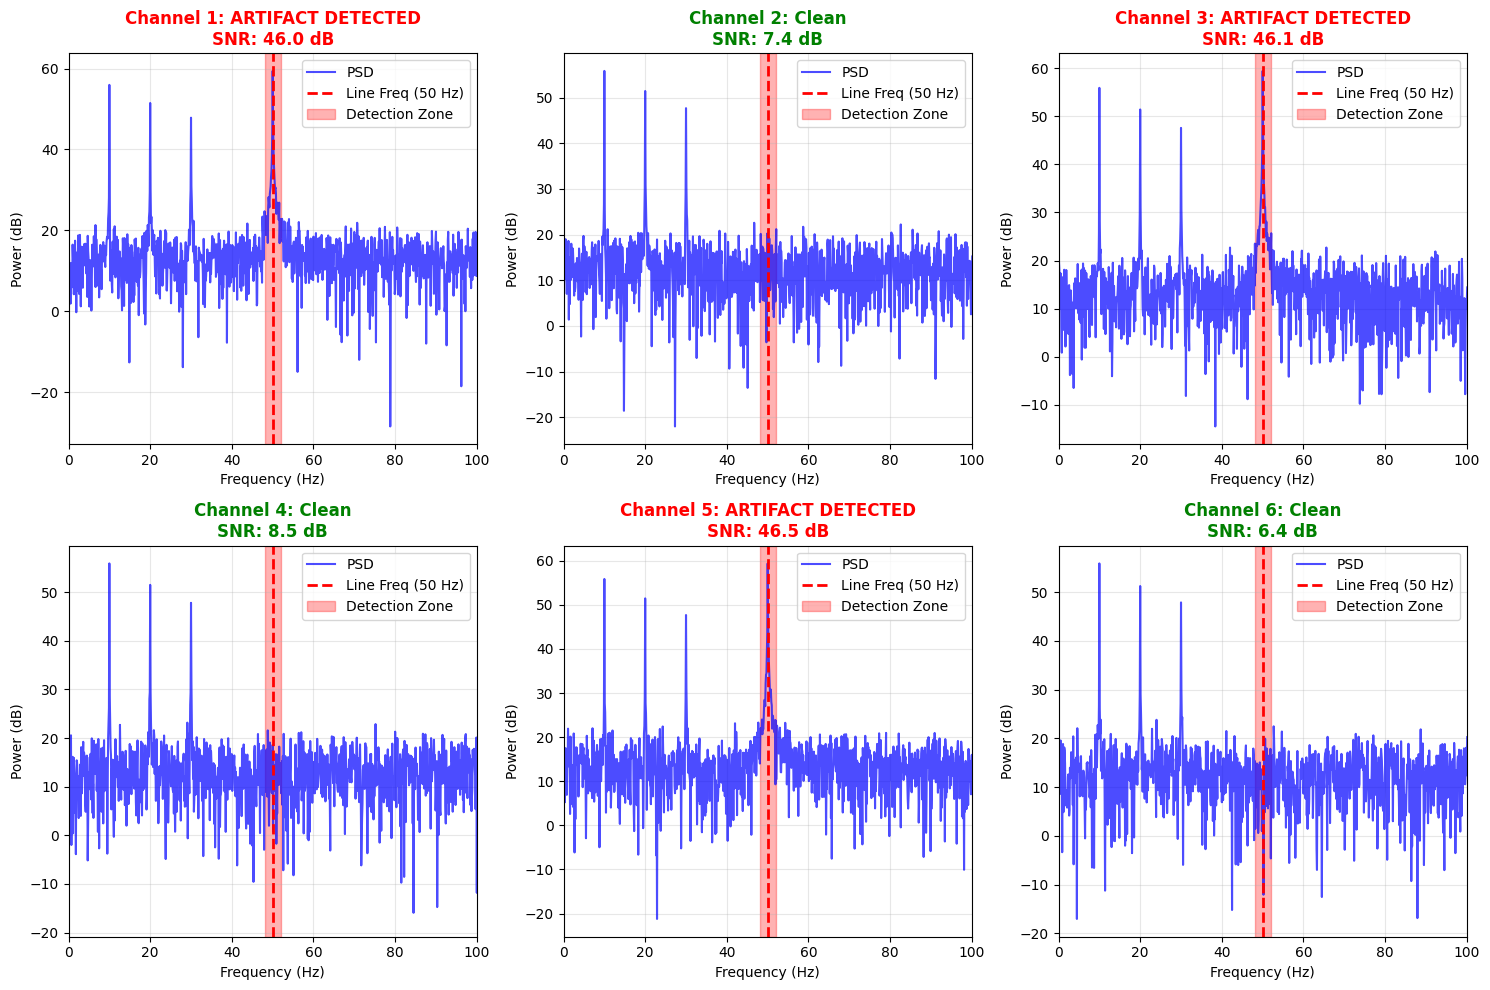

📊 LINE NOISE DETECTION RESULTS
Channel  Has Line Noise  Peak Freq (Hz)  Noise Power (dB)   SNR (dB)  
--------------------------------------------------------------------------------
Ch1      ✅ YES           50.00           59.42              45.99     
Ch2      ❌ NO            49.90           20.22              7.38      
Ch3      ✅ YES           50.00           59.45              46.11     
Ch4      ❌ NO            48.80           21.57              8.45      
Ch5      ✅ YES           50.00           59.41              46.52     
Ch6      ❌ NO            50.60           19.94              6.37      
--------------------------------------------------------------------------------

📈 SUMMARY:
   • Total channels analyzed: 6
   • Channels with line noise: 3
   • Contamination rate: 50.0%
   • Average SNR: 26.80 dB
   • Max SNR: 46.52 dB
   • Min SNR: 6.37 dB

⚠️  RECOMMENDATION: Apply notch filtering to remove line noise artifacts

🔍 DETAILED RESULTS ANALYSIS:

Channel 1:
  • Line noise

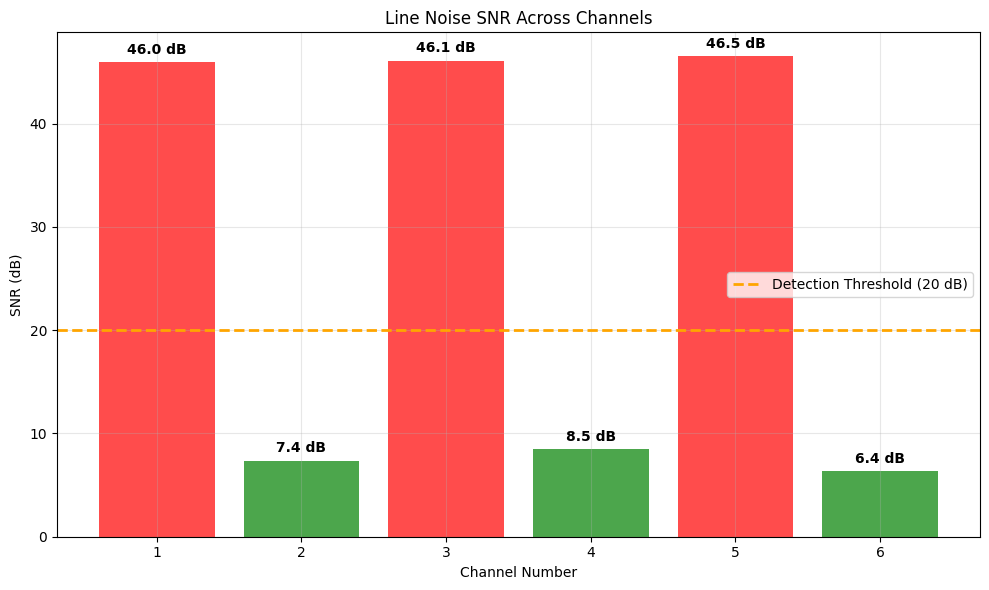

In [9]:
# Cell 2: Fungsi utama deteksi line noise (DIPERBAIKI)
def detect_line_noise(eeg_data, fs=250, line_freq=50, threshold_db=20):
    """
    Deteksi line frequency artifact pada sinyal EEG
    
    Parameters:
    - eeg_data: array EEG (channels x samples)
    - fs: sampling frequency
    - line_freq: frekuensi line noise (50 Hz atau 60 Hz)
    - threshold_db: threshold dalam dB untuk deteksi artifact
    """
    
    n_channels, n_samples = eeg_data.shape
    freqs = fftfreq(n_samples, 1/fs)
    
    # Region frekuensi sekitar line frequency
    freq_range = [line_freq-2, line_freq+2]
    freq_mask = (freqs >= freq_range[0]) & (freqs <= freq_range[1])
    
    results = {
        'has_line_noise': [],
        'noise_power_db': [],
        'peak_frequency': [],
        'signal_to_noise_ratio': []
    }
    
    plt.figure(figsize=(15, 10))
    
    for ch_idx in range(min(6, n_channels)):  # Analisis 6 channel pertama
        channel_data = eeg_data[ch_idx]
        
        # FFT
        fft_vals = fft(channel_data)
        fft_power = np.abs(fft_vals)**2
        fft_db = 10 * np.log10(fft_power + 1e-10)  # + epsilon untuk hindari log(0)
        
        # Power di region line frequency
        line_power_db = np.max(fft_db[freq_mask])
        
        # Power di region baseline (10-40 Hz)
        baseline_mask = (freqs >= 10) & (freqs <= 40)
        baseline_power_db = np.median(fft_db[baseline_mask])
        
        # Signal-to-noise ratio
        snr = line_power_db - baseline_power_db
        
        # Deteksi artifact
        has_artifact = snr > threshold_db
        peak_freq = freqs[freq_mask][np.argmax(fft_db[freq_mask])]
        
        results['has_line_noise'].append(has_artifact)
        results['noise_power_db'].append(line_power_db)
        results['peak_frequency'].append(peak_freq)
        results['signal_to_noise_ratio'].append(snr)
        
        # Plot PSD untuk channel ini
        plt.subplot(2, 3, ch_idx+1)
        plt.plot(freqs[:n_samples//2], fft_db[:n_samples//2], 'b-', alpha=0.7, label='PSD')
        plt.axvline(line_freq, color='red', linestyle='--', linewidth=2, 
                   label=f'Line Freq ({line_freq} Hz)')
        plt.axvspan(line_freq-2, line_freq+2, alpha=0.3, color='red', label='Detection Zone')
        
        if has_artifact:
            plt.title(f'Channel {ch_idx+1}: ARTIFACT DETECTED\nSNR: {snr:.1f} dB', 
                     color='red', fontweight='bold')
        else:
            plt.title(f'Channel {ch_idx+1}: Clean\nSNR: {snr:.1f} dB', 
                     color='green', fontweight='bold')
            
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Power (dB)')
        plt.xlim(0, 100)
        plt.grid(True, alpha=0.3)
        plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return results

# Cell 2b: Fungsi untuk menampilkan results dengan format yang rapi
def print_line_noise_results(results):
    """Menampilkan hasil deteksi line noise dalam format tabel"""
    
    print("📊 LINE NOISE DETECTION RESULTS")
    print("=" * 80)
    print(f"{'Channel':<8} {'Has Line Noise':<15} {'Peak Freq (Hz)':<15} {'Noise Power (dB)':<18} {'SNR (dB)':<10}")
    print("-" * 80)
    
    for i in range(len(results['has_line_noise'])):
        channel = f"Ch{i+1}"
        has_noise = "✅ YES" if results['has_line_noise'][i] else "❌ NO"
        peak_freq = f"{results['peak_frequency'][i]:.2f}"
        noise_power = f"{results['noise_power_db'][i]:.2f}"
        snr = f"{results['signal_to_noise_ratio'][i]:.2f}"
        
        print(f"{channel:<8} {has_noise:<15} {peak_freq:<15} {noise_power:<18} {snr:<10}")
    
    print("-" * 80)
    
    # Summary statistics
    total_channels = len(results['has_line_noise'])
    noisy_channels = sum(results['has_line_noise'])
    contamination_rate = (noisy_channels / total_channels) * 100
    
    print(f"\n📈 SUMMARY:")
    print(f"   • Total channels analyzed: {total_channels}")
    print(f"   • Channels with line noise: {noisy_channels}")
    print(f"   • Contamination rate: {contamination_rate:.1f}%")
    print(f"   • Average SNR: {np.mean(results['signal_to_noise_ratio']):.2f} dB")
    print(f"   • Max SNR: {np.max(results['signal_to_noise_ratio']):.2f} dB")
    print(f"   • Min SNR: {np.min(results['signal_to_noise_ratio']):.2f} dB")
    
    # Recommendation
    if noisy_channels > 0:
        print(f"\n⚠️  RECOMMENDATION: Apply notch filtering to remove line noise artifacts")
    else:
        print(f"\n✅ RECOMMENDATION: No significant line noise detected")

# Cell 2c: Test dengan data sintetis (jika belum punya data real)
def test_line_noise_detection():
    """Test fungsi deteksi dengan data sintetis"""
    
    # Generate synthetic EEG data dengan line noise
    fs = 250
    t = np.linspace(0, 10, 10 * fs)  # 10 detik
    n_channels = 6
    
    # Buat data sintetis
    eeg_data = np.zeros((n_channels, len(t)))
    
    for ch in range(n_channels):
        # EEG baseline (alpha, beta waves)
        eeg_baseline = (0.5 * np.sin(2 * np.pi * 10 * t) +  # 10 Hz alpha
                        0.3 * np.sin(2 * np.pi * 20 * t) +  # 20 Hz beta
                        0.2 * np.sin(2 * np.pi * 30 * t))   # 30 Hz gamma
        
        # Tambahkan line noise hanya di channel 1, 3, 5
        if ch in [0, 2, 4]:  # Channel 1, 3, 5
            line_noise = 0.8 * np.sin(2 * np.pi * 50 * t)  # 50 Hz line noise
        else:
            line_noise = 0  # No line noise
            
        # Tambahkan noise random
        random_noise = 0.1 * np.random.randn(len(t))
        
        eeg_data[ch] = eeg_baseline + line_noise + random_noise
    
    print("🧪 TESTING WITH SYNTHETIC DATA")
    print(f"Data shape: {eeg_data.shape}")
    print(f"Sampling rate: {fs} Hz")
    
    # Run detection
    results = detect_line_noise(eeg_data, fs=fs, line_freq=50, threshold_db=20)
    
    # Print results
    print_line_noise_results(results)
    
    return eeg_data, results

# Cell 2d: Jalankan test
print("🚀 RUNNING LINE NOISE DETECTION TEST...")
eeg_data, results = test_line_noise_detection()

# Cell 2e: Tampilkan results secara detail
print("\n🔍 DETAILED RESULTS ANALYSIS:")
print("=" * 50)

for i in range(len(results['has_line_noise'])):
    print(f"\nChannel {i+1}:")
    print(f"  • Line noise detected: {results['has_line_noise'][i]}")
    print(f"  • Peak frequency: {results['peak_frequency'][i]:.2f} Hz")
    print(f"  • Noise power: {results['noise_power_db'][i]:.2f} dB")
    print(f"  • SNR: {results['signal_to_noise_ratio'][i]:.2f} dB")
    print(f"  • Status: {'⚠️ NEEDS FILTERING' if results['has_line_noise'][i] else '✅ CLEAN'}")

# Cell 2f: Visualisasi tambahan - Distribution of SNR values
plt.figure(figsize=(10, 6))
channels = range(1, len(results['signal_to_noise_ratio']) + 1)
colors = ['red' if has_noise else 'green' for has_noise in results['has_line_noise']]

plt.bar(channels, results['signal_to_noise_ratio'], color=colors, alpha=0.7)
plt.axhline(y=20, color='orange', linestyle='--', linewidth=2, label='Detection Threshold (20 dB)')
plt.xlabel('Channel Number')
plt.ylabel('SNR (dB)')
plt.title('Line Noise SNR Across Channels')
plt.legend()
plt.grid(True, alpha=0.3)

# Annotate bars dengan values
for i, v in enumerate(results['signal_to_noise_ratio']):
    plt.text(i + 1, v + 0.5, f'{v:.1f} dB', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [3]:
# Cell 3: Time-frequency analysis untuk line noise
def plot_time_frequency_analysis(eeg_data, fs=250, line_freq=50):
    """Analisis time-frequency untuk melihat persistensi line noise"""
    
    n_channels = min(4, eeg_data.shape[0])
    
    fig, axes = plt.subplots(n_channels, 2, figsize=(16, 3*n_channels))
    
    for ch_idx in range(n_channels):
        channel_data = eeg_data[ch_idx]
        
        # Plot time domain
        if n_channels == 1:
            ax_time = axes[0]
            ax_spec = axes[1]
        else:
            ax_time = axes[ch_idx, 0]
            ax_spec = axes[ch_idx, 1]
        
        # Time domain plot
        time_axis = np.arange(len(channel_data)) / fs
        ax_time.plot(time_axis, channel_data)
        ax_time.set_xlabel('Time (s)')
        ax_time.set_ylabel('Amplitude')
        ax_time.set_title(f'Channel {ch_idx+1} - Time Domain')
        ax_time.grid(True, alpha=0.3)
        
        # Spectrogram
        f, t, Sxx = signal.spectrogram(channel_data, fs=fs, nperseg=256, noverlap=128)
        im = ax_spec.pcolormesh(t, f, 10*np.log10(Sxx+1e-10), shading='gouraud', cmap='viridis')
        ax_spec.axhline(line_freq, color='red', linestyle='--', linewidth=2, 
                       label=f'{line_freq} Hz Line')
        ax_spec.set_ylabel('Frequency [Hz]')
        ax_spec.set_xlabel('Time [sec]')
        ax_spec.set_title(f'Channel {ch_idx+1} - Spectrogram')
        ax_spec.set_ylim(0, 100)
        ax_spec.legend()
        plt.colorbar(im, ax=ax_spec, label='Power (dB)')
    
    plt.tight_layout()
    plt.show()

In [4]:
# Cell 4: Perbandingan sebelum dan sesudah filtering
def apply_notch_filter_comparison(eeg_data, fs=250, line_freq=50):
    """Aplikasi notch filter dan perbandingan visual"""
    
    # Design notch filter
    Q = 30.0  # Quality factor
    w0 = line_freq / (fs/2)  # Normalized frequency
    b, a = signal.iirnotch(w0, Q)
    
    # Apply filter
    filtered_data = signal.filtfilt(b, a, eeg_data, axis=1)
    
    # Plot comparison untuk channel pertama
    channel_idx = 0
    original = eeg_data[channel_idx]
    filtered = filtered_data[channel_idx]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Time domain comparison
    time_axis = np.arange(len(original)) / fs
    axes[0, 0].plot(time_axis, original, 'b-', alpha=0.7, label='Original')
    axes[0, 0].plot(time_axis, filtered, 'r-', alpha=0.7, label='Filtered')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Amplitude')
    axes[0, 0].set_title('Time Domain: Before vs After Notch Filter')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Frequency domain comparison
    freqs = fftfreq(len(original), 1/fs)
    fft_original = np.abs(fft(original))**2
    fft_filtered = np.abs(fft(filtered))**2
    
    axes[0, 1].semilogy(freqs[:len(freqs)//2], fft_original[:len(freqs)//2], 
                       'b-', alpha=0.7, label='Original')
    axes[0, 1].semilogy(freqs[:len(freqs)//2], fft_filtered[:len(freqs)//2], 
                       'r-', alpha=0.7, label='Filtered')
    axes[0, 1].axvline(line_freq, color='red', linestyle='--', label=f'{line_freq} Hz')
    axes[0, 1].set_xlabel('Frequency (Hz)')
    axes[0, 1].set_ylabel('Power')
    axes[0, 1].set_title('Frequency Domain: Before vs After Notch Filter')
    axes[0, 1].set_xlim(0, 100)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Zoom around line frequency
    freq_mask = (freqs >= line_freq-10) & (freqs <= line_freq+10)
    axes[1, 0].plot(freqs[freq_mask], fft_original[freq_mask], 'bo-', label='Original')
    axes[1, 0].plot(freqs[freq_mask], fft_filtered[freq_mask], 'ro-', label='Filtered')
    axes[1, 0].axvline(line_freq, color='red', linestyle='--', label=f'{line_freq} Hz')
    axes[1, 0].set_xlabel('Frequency (Hz)')
    axes[1, 0].set_ylabel('Power')
    axes[1, 0].set_title(f'Zoom: {line_freq-10}-{line_freq+10} Hz Region')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # SNR improvement
    original_snr = np.max(fft_original[freq_mask]) / np.median(fft_original[freq_mask])
    filtered_snr = np.max(fft_filtered[freq_mask]) / np.median(fft_filtered[freq_mask])
    
    axes[1, 1].bar(['Before Filter', 'After Filter'], [original_snr, filtered_snr], 
                  color=['blue', 'red'], alpha=0.7)
    axes[1, 1].set_ylabel('Line Noise SNR Ratio')
    axes[1, 1].set_title(f'SNR Improvement: {((original_snr-filtered_snr)/original_snr*100):.1f}% Reduction')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return filtered_data

In [5]:
# Cell 5: Laporan komprehensif line noise
def comprehensive_line_noise_report(eeg_data, fs=250, line_freq=50):
    """Laporan lengkap analisis line noise"""
    
    print("🔍 COMPREHENSIVE LINE NOISE ANALYSIS REPORT")
    print("=" * 60)
    
    # 1. Deteksi line noise
    print("\n1. LINE NOISE DETECTION RESULTS:")
    detection_results = detect_line_noise(eeg_data, fs, line_freq)
    
    # 2. Summary statistics
    print("\n2. SUMMARY STATISTICS:")
    noisy_channels = np.sum(detection_results['has_line_noise'])
    total_channels = len(detection_results['has_line_noise'])
    
    print(f"   • Total channels analyzed: {total_channels}")
    print(f"   • Channels with line noise: {noisy_channels}")
    print(f"   • Contamination rate: {(noisy_channels/total_channels*100):.1f}%")
    print(f"   • Average SNR: {np.mean(detection_results['signal_to_noise_ratio']):.1f} dB")
    print(f"   • Max SNR: {np.max(detection_results['signal_to_noise_ratio']):.1f} dB")
    
    # 3. Time-frequency analysis
    print("\n3. TIME-FREQUENCY ANALYSIS:")
    plot_time_frequency_analysis(eeg_data, fs, line_freq)
    
    # 4. Filtering comparison
    print("\n4. NOTCH FILTERING COMPARISON:")
    filtered_data = apply_notch_filter_comparison(eeg_data, fs, line_freq)
    
    # 5. Recommendation
    print("\n5. RECOMMENDATION:")
    if noisy_channels > 0:
        print("   ⚠️  Line noise artifacts detected!")
        print("   ✅ Recommended: Apply notch filtering at {} Hz".format(line_freq))
        print("   📊 Affected channels: {}".format(
            [i+1 for i, has_noise in enumerate(detection_results['has_line_noise']) if has_noise]
        ))
    else:
        print("   ✅ No significant line noise detected")
        print("   ℹ️  No filtering required")
    
    return detection_results, filtered_data

In [6]:
# Cell 6: Eksekusi utama pada dataset BCI Competition IV
def analyze_bci_dataset():
    """Analisis line noise pada dataset BCI Competition IV"""
    
    data_path = Path(r"C:\Users\akip\Desktop\EEGdenoiseNet\Data BCI Competition IV")
    
    # Cari file .mat atau .gdf
    mat_files = list(data_path.glob("*.mat"))
    gdf_files = list(data_path.glob("*.gdf"))
    
    if mat_files:
        print("📁 Found MAT files, analyzing first file...")
        file_path = mat_files[0]
        
        # Load data
        data = sio.loadmat(file_path)
        keys = [k for k in data.keys() if not k.startswith('__')]
        
        if keys:
            eeg_data = data[keys[0]]
            print(f"📊 Data shape: {eeg_data.shape}")
            
            # Asumsi sampling rate untuk BCI Competition IV
            fs = 250  # Hz (typical for BCI datasets)
            line_freq = 50  # Hz (assuming European power system)
            
            # Run comprehensive analysis
            results, filtered = comprehensive_line_noise_report(eeg_data, fs, line_freq)
            
    elif gdf_files:
        print("📁 Found GDF files, analyzing first file...")
        file_path = gdf_files[0]
        
        # Load GDF data
        raw = mne.io.read_raw_gdf(file_path, preload=True, verbose=False)
        eeg_data = raw.get_data()
        
        fs = raw.info['sfreq']
        line_freq = 50  # atau 60 tergantung lokasi
        
        print(f"📊 Data shape: {eeg_data.shape}")
        print(f"📊 Sampling rate: {fs} Hz")
        
        # Run comprehensive analysis
        results, filtered = comprehensive_line_noise_report(eeg_data, fs, line_freq)
        
    else:
        print("❌ No EEG files found in the directory")

# Jalankan analisis
analyze_bci_dataset()

❌ No EEG files found in the directory


In [ ]:
# Cell 7: Tool diagnostik cepat
def quick_line_noise_check(eeg_data, fs=250, line_freq=50):
    """Check cepat line noise untuk satu channel"""
    
    channel_data = eeg_data[0]  # Channel pertama
    freqs = fftfreq(len(channel_data), 1/fs)
    
    # FFT analysis
    fft_vals = fft(channel_data)
    fft_power = np.abs(fft_vals)**2
    fft_db = 10 * np.log10(fft_power + 1e-10)
    
    # Check line frequency region
    freq_mask = (freqs >= line_freq-1) & (freqs <= line_freq+1)
    line_power = np.max(fft_db[freq_mask])
    
    # Check baseline
    baseline_mask = (freqs >= 45) & (freqs <= 49) | (freqs >= 51) & (freqs <= 55)
    baseline_power = np.median(fft_db[baseline_mask])
    
    snr = line_power - baseline_power
    
    # Simple plot
    plt.figure(figsize=(10, 6))
    plt.plot(freqs[:len(freqs)//2], fft_db[:len(freqs)//2], 'b-')
    plt.axvline(line_freq, color='red', linestyle='--', linewidth=2, 
               label=f'{line_freq} Hz Line Noise')
    plt.axvspan(line_freq-1, line_freq+1, alpha=0.3, color='red')
    plt.xlim(0, 100)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power (dB)')
    plt.title(f'Quick Line Noise Check\nSNR: {snr:.1f} dB - {"ARTIFACT" if snr > 20 else "CLEAN"}')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    print(f"🔍 Quick Diagnosis:")
    print(f"   • Line frequency power: {line_power:.1f} dB")
    print(f"   • Baseline power: {baseline_power:.1f} dB") 
    print(f"   • SNR: {snr:.1f} dB")
    print(f"   • Status: {'⚠️ ARTIFACT DETECTED' if snr > 20 else '✅ CLEAN'}")

# Contoh quick check
# quick_line_noise_check(eeg_data)

NameError: name 'eeg_data' is not defined